In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import cv2
import logging
from math import cos, sin, atan2, sqrt
import os

In [33]:
scan = pd.read_csv("files/scan.csv")
print(scan.head())

                  t_ns  angle_min  angle_inc   r0   r1   r2   r3   r4   r5  \
0  1771970259546107435      -3.14   0.017493  inf  inf  inf  inf  inf  inf   
1  1771970259548293604      -3.14   0.017493  inf  inf  inf  inf  inf  inf   
2  1771970259924411242      -3.14   0.017493  inf  inf  inf  inf  inf  inf   
3  1771970260371970673      -3.14   0.017493  inf  inf  inf  inf  inf  inf   
4  1771970260548317064      -3.14   0.017493  inf  inf  inf  inf  inf  inf   

    r6  ...      r350      r351      r352      r353      r354      r355  \
0  inf  ...  3.154634  3.146277  3.138921  3.132555  3.127170  3.122758   
1  inf  ...  3.154655  3.146296  3.138940  3.132575  3.127189  3.122777   
2  inf  ...  3.154647  3.146288  3.138932  3.132566  3.127182  3.122769   
3  inf  ...  3.154612  3.146254  3.138897  3.132531  3.127146  3.122733   
4  inf  ...  3.154605  3.146246  3.138889  3.132523  3.127138  3.122725   

       r356      r357      r358  r359  
0  3.119312  3.116825  3.640858   inf  


In [34]:
odom = pd.read_csv("files/odom.csv")
print(odom.head())

                  t_ns         x         y       yaw        vx        wz
0  1771970259546758904 -0.259115  0.012268 -0.094643 -0.000081 -0.000036
1  1771970259548513561 -0.259147  0.012271 -0.094644 -0.000081 -0.000036
2  1771970259548558973 -0.259121  0.012268 -0.094645 -0.000081 -0.000036
3  1771970259549006889 -0.259153  0.012271 -0.094647 -0.000081 -0.000036
4  1771970259578917270 -0.259127  0.012269 -0.094648 -0.000081 -0.000036


In [35]:
tf = pd.read_csv("files/tf.csv")
tf = tf[(tf["child"] == "robot1/base_link") & (tf["parent"] == "robot1/odom")]
print(tf.head())

                   t_ns       parent             child        tx        ty  \
0   1771970259762743088  robot1/odom  robot1/base_link -0.259159  0.012272   
1   1771970259911077874  robot1/odom  robot1/base_link -0.259133  0.012269   
9   1771970260053355975  robot1/odom  robot1/base_link -0.259165  0.012272   
10  1771970260287224960  robot1/odom  robot1/base_link -0.259138  0.012270   
11  1771970260389589039  robot1/odom  robot1/base_link -0.259170  0.012273   

     tz       yaw  
0   0.0 -0.094649  
1   0.0 -0.094650  
9   0.0 -0.094652  
10  0.0 -0.094653  
11  0.0 -0.094654  


In [36]:
obstacles = pd.read_csv("files/map_obstacles.csv")
print(obstacles.head())

                  t_ns         x         y  row  col  occupancy
0  1771970261302923084 -9.274242 -10.88494  345  118        100
1  1771970261302923084 -9.235772 -10.88494  345  119        100
2  1771970261302923084 -9.197302 -10.88494  345  120        100
3  1771970261302923084 -9.158832 -10.88494  345  121        100
4  1771970261302923084 -9.120362 -10.88494  345  122        100


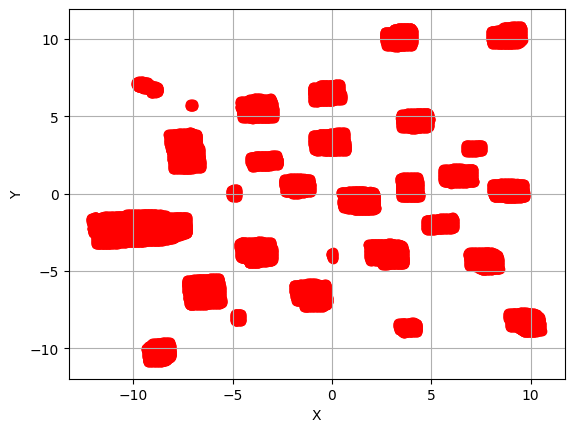

In [37]:
# plot obstacles
obs = obstacles[obstacles["t_ns"] == 1771970261302923084]
plt.scatter(obs["x"], obs["y"], c="red", label="Obstacles")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

In [38]:
def get_scan_for_odom(t_ns):
    # find the closest scan in scan
    idx = (np.abs(scan["t_ns"] - t_ns)).argmin()
    print(f"Closest scan has a delta of {(scan['t_ns'][idx] - t_ns) / 1e9} seconds")
    return scan.iloc[idx]


In [39]:
def get_obstacles_for_odom(t_ns):
    # find the closest obstacles in obstacles
    idx = (np.abs(obstacles["t_ns"] - t_ns)).argmin()
    print(f"Closest obstacles has a delta of {(obstacles['t_ns'][idx] - t_ns) / 1e9} seconds")
    return obstacles[obstacles["t_ns"] == obstacles["t_ns"][idx]]

In [40]:
get_obstacles_for_odom(1771970261302923084)

Closest obstacles has a delta of 0.0 seconds


,t_ns,x,y,row,col,occupancy
0,1771970261302923084,-9.274242,-10.884940,345,118,100
1,1771970261302923084,-9.235772,-10.884940,345,119,100
2,1771970261302923084,-9.197302,-10.884940,345,120,100
3,1771970261302923084,-9.158832,-10.884940,345,121,100
4,1771970261302923084,-9.120362,-10.884940,345,122,100
...,...,...,...,...,...,...
31990,1771970261302923084,9.383773,10.850685,910,603,100
31991,1771970261302923084,9.422243,10.850685,910,604,100
31992,1771970261302923084,9.460713,10.850685,910,605,100
31993,1771970261302923084,9.499183,10.850685,910,606,100


In [41]:
map_info = pd.read_csv("files/map_info.csv")
print(map_info.head())

                  t_ns                        image_file  resolution  width  \
0  1771970261302923084  map_0001_1771970261302923084.png    0.038470    780   
1  1771970262676835950  map_0002_1771970262676835950.png    0.038477    780   
2  1771970264338306300  map_0003_1771970264338306300.png    0.038477    780   
3  1771970275057061199  map_0004_1771970275057061199.png    0.038361    779   
4  1771970276683722140  map_0005_1771970276683722140.png    0.038375    779   

   height   origin_x   origin_y  
0    1313 -13.832953 -24.176372  
1    1313 -13.832458 -24.179622  
2    1313 -13.833145 -24.180321  
3    1313 -13.785823 -24.102653  
4    1313 -13.788734 -24.110678  


In [42]:
def get_odom(t_ns):
    match_odom = odom[odom["t_ns"] == t_ns]
    x = float(match_odom["x"].values[0])
    y = float(match_odom["y"].values[0])
    theta = float(match_odom["yaw"].values[0])
    return x,y,theta

 

In [43]:
def get_odom_transform(x, y, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]], dtype=float)
    t = np.array([x, y-4], dtype=float)
    return R, t

In [44]:
def get_point_from_scan(t_ns):
    match_scan = get_scan_for_odom(t_ns)
    points = []
    angle = match_scan["angle_min"]

    # loop on match_scan columns starting from the 4th column and compute the x and y coordinates of the points in the scan and store them in a list
    for r in match_scan[3:].values:
        if np.isnan(r) or np.isinf(r):
            angle += match_scan["angle_inc"]
            continue

        x = r * cos(angle)
        y = r* sin(angle)

        points.append([x,y])

        angle += match_scan["angle_inc"]

    return (np.array(points))
        


In [45]:
def compute_transformation(P, Q):
        p_mean = np.mean(P,axis=0)
        q_mean = np.mean(Q, axis=0)

        P_centered = P - p_mean
        Q_centered = Q - q_mean

        H = P_centered.T @ Q_centered

        U, _, Vt = np.linalg.svd(H)
        V = Vt.T

        R = V @ U.T
        if np.linalg.det(R) < 0:
            S = np.diag([1, -1])
            R = V @ S @ U.T
        
        t = q_mean - R @ p_mean

        return R, t

In [46]:

def get_map_obstacles_for_odom(t_ns):

    image_files = os.listdir("files/map_images")
    t_ns_list = []
    for image_file in image_files:
        t = int(image_file.split("_")[2].split(".")[0])
        # store t_ns and corresponding image file in a list of tuples
        t_ns_list.append({'t':t, 'image_file': image_file})

    idx = (np.abs(np.array([d['t'] for d in t_ns_list]) - t_ns)).argmin()
    print(f"Closest map is {t_ns_list[idx]['image_file']} has a delta of {(t_ns_list[idx]['t'] - t_ns) / 1e9} seconds")
    map = cv2.imread(f"files/map_images/{t_ns_list[idx]['image_file']}",cv2.IMREAD_GRAYSCALE)
    _, bw = cv2.threshold(map, 200, 255, cv2.THRESH_BINARY_INV)

    # (optional) clean tiny noise
    kernel = np.ones((3, 3), np.uint8)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # white canvas
    out = np.full_like(map, 255)

    # draw ALL contours
    cv2.drawContours(out, contours, -1, 0, thickness=1)

    resolution = map_info[map_info['t_ns'] == t_ns_list[idx]['t']]['resolution'].values[0]
    origin_x = map_info[map_info['t_ns'] == t_ns_list[idx]['t']]['origin_x'].values[0]
    origin_y = map_info[map_info['t_ns'] == t_ns_list[idx]['t']]['origin_y'].values[0]
    points = []

    # get x and y of none black pixels in out and convert them to world coordinates
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            if out[i][j] != 255:  # if pixel is not white (i.e., is black)
                x = origin_x + j * resolution
                y = origin_y + (out.shape[0]-i-1) * resolution
                points.append([x,y])

    return np.array(points)

In [47]:
get_map_obstacles_for_odom(1771970261302923084)

Closest map is map_0001_1771970261302923084.png has a delta of 0.0 seconds


array([[  9.01830668,  10.83145042],
       [  9.05677682,  10.83145042],
       [  9.09524695,  10.83145042],
       ...,
       [ -8.63948489, -10.90417537],
       [ -8.60101475, -10.90417537],
       [ -8.56254462, -10.90417537]], shape=(3634, 2))

Closest map is map_0001_1771970261302923084.png has a delta of 0.0 seconds


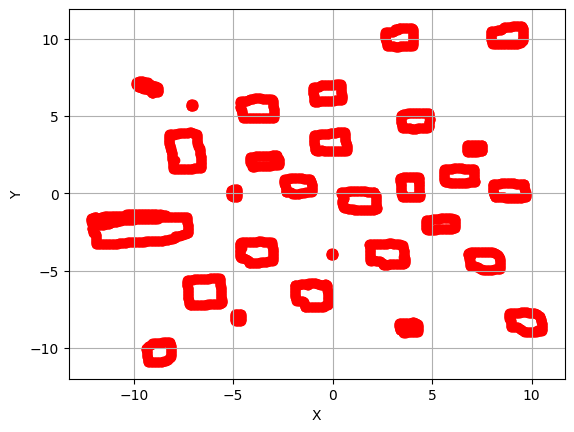

In [48]:
map = get_map_obstacles_for_odom(1771970261302923084)
# plot image of map and points of obstacles
plt.scatter(map[:,0], map[:,1], c="red", label="Obstacles")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

In [49]:
height = map_info[map_info['t_ns'] == 1771970261302923084]['height'].values[0]  
print(height)

1313


In [50]:
def icp_pose(source, target,R_od,t_od, max_iterations=50, plot=False, max_corr_dist=2.0):

    R_total = np.eye(2)
    t_total = np.zeros(2)
    src = (R_od @ source.T).T + t_od

    tree = KDTree(target)

    mean_error = float("inf")
    mean_error_initial = float("inf")

    x_icp = float(t_od[0])
    y_icp = float(t_od[1])
    theta_icp = float(atan2(R_od[1,0], R_od[0,0]))

    x_icp_initial = float(t_od[0])
    y_icp_initial = float(t_od[1])
    theta_icp_initial = float(atan2(R_od[1,0], R_od[0,0]))
    source_initial = src.copy()

    i = -1
    for i in range(max_iterations):
        src_prev = src.copy()
        R_prev = R_total.copy()
        t_prev = t_total.copy()

        prev_mean_error = mean_error

        distances, indices = tree.query(src)
        valid_mask = distances < max_corr_dist
        if np.count_nonzero(valid_mask) == 0:
            break

        src_matched = src[valid_mask]
        target_matched = target[indices[valid_mask]]

        R,t = compute_transformation(src_matched, target_matched)
        src_candidate = (R @ src.T).T + t

        distances2, _ = tree.query(src_candidate)
        valid_mask2 = distances2 < max_corr_dist
        if np.count_nonzero(valid_mask2) == 0:
            src = src_prev
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break

        mean_error_candidate = float(np.sqrt(np.mean(distances2[valid_mask2]**2)))

        if mean_error_candidate > prev_mean_error * (1 + 1e-20):
            src = src_prev
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break

        src = src_candidate
        mean_error = mean_error_candidate

        R_total = R @ R_total
        t_total = R @ t_total + t

        R_icp = R_total @ R_od
        t_icp = R_total @ t_od + t_total

        x_icp = float(t_icp[0])
        y_icp = float(t_icp[1])
        theta_icp = float(atan2(R_icp[1,0], R_icp[0,0]))
        if i == 0:
            x_icp_initial = float(t_od[0])
            y_icp_initial = float(t_od[1])
            theta_icp_initial = float(atan2(R_od[1,0], R_od[0,0]))
            source_initial = ((R_od @ source.T).T + t_od).copy()
            mean_error_initial = mean_error

    print(f'mean_error: {mean_error} after {i} iterations;initial mean error: {mean_error_initial}')

    if plot ==True:

        # plot side by side initial and final sources and poses
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.arrow(x_icp_initial, y_icp_initial, 0.5*np.cos(theta_icp_initial), 0.5*np.sin(theta_icp_initial), head_width=0.2, head_length=0.2, fc='green', ec='green') 
        plt.scatter(x_icp_initial, y_icp_initial, c="green", label="ICP Initial Position", s=30)
        plt.arrow(t_od[0], t_od[1], 0.5*np.cos(atan2(R_od[1,0], R_od[0,0])), 0.5*np.sin(atan2(R_od[1,0], R_od[0,0])), head_width=0.2, head_length=0.2, fc='blue', ec='blue')  
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)
        plt.scatter(target[:,0], target[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(source_initial[:,0], source_initial[:,1], c="red", label="Initial Scan Points", s=1)
        plt.title(f"Initial iteration: ICP and Odometry Positions,mean error: {mean_error_initial:.4f}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.grid()

        plt.subplot(1,2,2)
            # plot icp pose as a blue arrow
        plt.arrow(x_icp, y_icp, 0.5*np.cos(theta_icp), 0.5*np.sin(theta_icp), head_width=0.2, head_length=0.2, fc='green', ec='green') 
        plt.scatter(x_icp, y_icp, c="green", label="ICP Final Position", s=30)
        plt.arrow(t_od[0], t_od[1], 0.5*np.cos(atan2(R_od[1,0], R_od[0,0])), 0.5*np.sin(atan2(R_od[1,0], R_od[0,0])), head_width=0.2, head_length=0.2, fc='blue', ec='blue')  
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)
        plt.scatter(target[:,0], target[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(src[:,0], src[:,1], c="red", label="Scan Points", s=1)
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(f"Final Iteration {i}: ICP and Odometry Positions,mean error: {mean_error:.4f}")
        plt.legend()
        plt.grid()
        plt.show()    

    return {"x": x_icp, "y": y_icp, "theta": theta_icp, "mean_error": mean_error, "initial_x": x_icp_initial, "initial_y": y_icp_initial, "initial_theta": theta_icp_initial, "mean_error_initial": mean_error_initial, "odom_x": t_od[0], "odom_y": t_od[1], "odom_theta": atan2(R_od[1,0], R_od[0,0])}


In [51]:
icp_results=[]
for t_ns in odom["t_ns"].values:
    target = get_map_obstacles_for_odom(t_ns)
    source = get_point_from_scan(t_ns)
    x_od,y_od,theta_od = get_odom(t_ns)
    R_od, t_od = get_odom_transform(x_od, y_od, theta_od)
    icp_result = icp_pose(source, target,R_od,t_od)
    icp_results.append(icp_result)
    print(f"Odometry pose in world: x={t_od[0]}, y={t_od[1]}, theta={atan2(R_od[1,0], R_od[0,0])}")
    print(f"ICP pose in world: x={icp_result['x']}, y={icp_result['y']}, theta={icp_result['theta']}")
icp_result_df = pd.DataFrame(icp_results)
icp_result_df.to_csv("icp_results_points_to_points.csv", index=False)

Closest map is map_0001_1771970261302923084.png has a delta of 1.75616418 seconds
Closest scan has a delta of -0.000651469 seconds
mean_error: 0.15903964980786994 after 16 iterations;initial mean error: 0.32302325102233875
Odometry pose in world: x=-0.2591152882920883, y=-3.987732419811621, theta=-0.0946427081665465
ICP pose in world: x=-0.08069187208126632, y=-4.001300451343169, theta=0.05649392310782561
Closest map is map_0001_1771970261302923084.png has a delta of 1.754409523 seconds
Closest scan has a delta of -0.000219957 seconds
mean_error: 0.15903532588531472 after 16 iterations;initial mean error: 0.32384645519913646
Odometry pose in world: x=-0.259147304380023, y=-3.987729380616852, theta=-0.0946443110206815
ICP pose in world: x=-0.08068764038253146, y=-4.001298004740562, theta=0.056494185287273686
Closest map is map_0001_1771970261302923084.png has a delta of 1.754364111 seconds
Closest scan has a delta of -0.000265369 seconds
mean_error: 0.1590353258853155 after 17 iteration

In [52]:
icp_result_df.head()

,x,y,theta,mean_error,initial_x,initial_y,initial_theta,mean_error_initial,odom_x,odom_y,odom_theta
0,-0.080692,-4.001300,0.056494,0.159040,-0.259115,-3.987732,-0.094643,0.323023,-0.259115,-3.987732,-0.094643
1,-0.080688,-4.001298,0.056494,0.159035,-0.259147,-3.987729,-0.094644,0.323846,-0.259147,-3.987729,-0.094644
2,-0.080688,-4.001298,0.056494,0.159035,-0.259121,-3.987732,-0.094645,0.323846,-0.259121,-3.987732,-0.094645
3,-0.080688,-4.001298,0.056494,0.159035,-0.259153,-3.987729,-0.094647,0.323846,-0.259153,-3.987729,-0.094647
4,-0.080688,-4.001298,0.056494,0.159035,-0.259127,-3.987731,-0.094648,0.323846,-0.259127,-3.987731,-0.094648


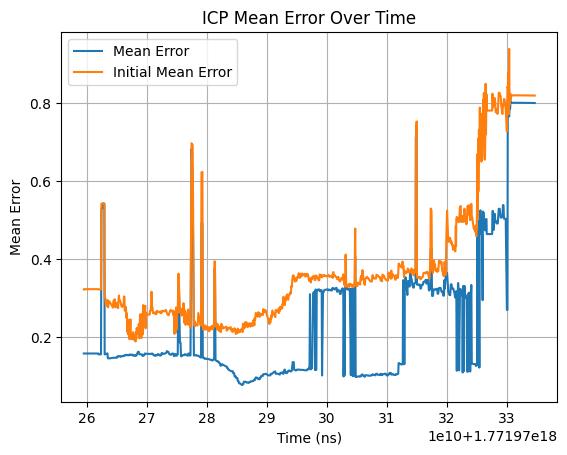

In [53]:
# plot mean error and initial mean error over time
icp_result_df = pd.read_csv("icp_results_points_to_points.csv")
plt.plot(odom["t_ns"].values, icp_result_df["mean_error"].values, label="Mean Error")
plt.plot(odom["t_ns"].values, icp_result_df["mean_error_initial"].values, label="Initial Mean Error")
plt.xlabel("Time (ns)")
plt.ylabel("Mean Error")
plt.title("ICP Mean Error Over Time")
plt.legend()
plt.grid()

/tmp/ipykernel_520519/3298684538.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])


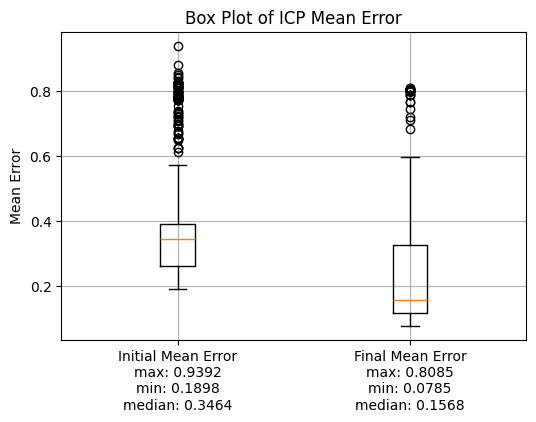

In [54]:
# box plot of mean error and initial mean error with values max min median 
plt.figure(figsize=(6,4))
## add values of max min and median to the box plot labels
initial_mean_error_max = np.max(icp_result_df["mean_error_initial"].values)
initial_mean_error_min = np.min(icp_result_df["mean_error_initial"].values)
initial_mean_error_median = np.median(icp_result_df["mean_error_initial"].values)
final_mean_error_max = np.max(icp_result_df["mean_error"].values)
final_mean_error_min = np.min(icp_result_df["mean_error"].values)
final_mean_error_median = np.median(icp_result_df["mean_error"].values)
plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])
plt.ylabel("Mean Error")
plt.title("Box Plot of ICP Mean Error")
plt.grid()
plt.show()

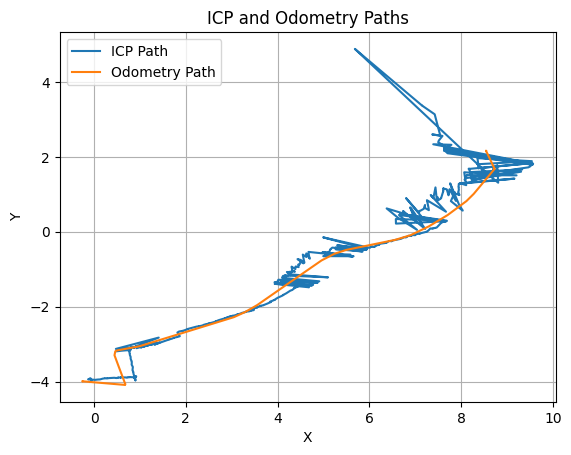

In [55]:
# plot icp and odom path over time
plt.plot(icp_result_df["x"].values, icp_result_df["y"].values, label="ICP Path")
plt.plot(icp_result_df["odom_x"].values, icp_result_df["odom_y"].values, label="Odometry Path")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("ICP and Odometry Paths")
plt.legend()
plt.grid()
plt.show()

In [56]:
def icp_pose_pairwise_rms(source, target,R_od,t_od, max_iterations=50, plot=False, max_corr_dist=2.0):

    R_total = np.eye(2)
    t_total = np.zeros(2)
    src = (R_od @ source.T).T + t_od

    tree = KDTree(target)

    mean_error = float("inf")
    mean_error_initial = float("inf")

    x_icp = float(t_od[0])
    y_icp = float(t_od[1])
    theta_icp = float(atan2(R_od[1,0], R_od[0,0]))

    x_icp_initial = float(t_od[0])
    y_icp_initial = float(t_od[1])
    theta_icp_initial = float(atan2(R_od[1,0], R_od[0,0]))
    source_initial = src.copy()

    i = -1
    for i in range(max_iterations):
        src_prev = src.copy()
        R_prev = R_total.copy()
        t_prev = t_total.copy()

        prev_mean_error = mean_error

        distances, indices = tree.query(src)
        valid_mask = distances < max_corr_dist
        if np.count_nonzero(valid_mask) == 0:
            break

        src_matched = src[valid_mask]
        target_matched = target[indices[valid_mask]]

        R,t = compute_transformation(src_matched, target_matched)

        pairwise_rmse_before = float(np.sqrt(np.mean(np.sum((src_matched - target_matched)**2, axis=1))))

        src_matched_after = (R @ src_matched.T).T + t
        pairwise_rmse_after = float(np.sqrt(np.mean(np.sum((src_matched_after - target_matched)**2, axis=1))))

        src_candidate = (R @ src.T).T + t

        if pairwise_rmse_after > pairwise_rmse_before * (1 + 1e-20):
            src = src_prev
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break

        distances2, _ = tree.query(src_candidate)
        valid_mask2 = distances2 < max_corr_dist
        if np.count_nonzero(valid_mask2) == 0:
            src = src_prev
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break

        mean_error_candidate = float(np.sqrt(np.mean(distances2[valid_mask2]**2)))

        if mean_error_candidate > prev_mean_error * (1 + 1e-20):
            src = src_prev
            R_total = R_prev
            t_total = t_prev
            mean_error = prev_mean_error
            break

        src = src_candidate
        mean_error = mean_error_candidate

        R_total = R @ R_total
        t_total = R @ t_total + t

        R_icp = R_total @ R_od
        t_icp = R_total @ t_od + t_total

        x_icp = float(t_icp[0])
        y_icp = float(t_icp[1])
        theta_icp = float(atan2(R_icp[1,0], R_icp[0,0]))
        if i == 0:
            x_icp_initial = float(t_od[0])
            y_icp_initial = float(t_od[1])
            theta_icp_initial = float(atan2(R_od[1,0], R_od[0,0]))
            source_initial = ((R_od @ source.T).T + t_od).copy()
            mean_error_initial = mean_error

    print(f'mean_error: {mean_error} after {i} iterations;initial mean error: {mean_error_initial}')

    if plot ==True:

        # plot side by side initial and final sources and poses
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.arrow(x_icp_initial, y_icp_initial, 0.5*np.cos(theta_icp_initial), 0.5*np.sin(theta_icp_initial), head_width=0.2, head_length=0.2, fc='green', ec='green') 
        plt.scatter(x_icp_initial, y_icp_initial, c="green", label="ICP Initial Position", s=30)
        plt.arrow(t_od[0], t_od[1], 0.5*np.cos(atan2(R_od[1,0], R_od[0,0])), 0.5*np.sin(atan2(R_od[1,0], R_od[0,0])), head_width=0.2, head_length=0.2, fc='blue', ec='blue')  
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)
        plt.scatter(target[:,0], target[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(source_initial[:,0], source_initial[:,1], c="red", label="Initial Scan Points", s=1)
        plt.title(f"Initial iteration: ICP and Odometry Positions,mean error: {mean_error_initial:.4f}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.grid()

        plt.subplot(1,2,2)
            # plot icp pose as a blue arrow
        plt.arrow(x_icp, y_icp, 0.5*np.cos(theta_icp), 0.5*np.sin(theta_icp), head_width=0.2, head_length=0.2, fc='green', ec='green') 
        plt.scatter(x_icp, y_icp, c="green", label="ICP Final Position", s=30)
        plt.arrow(t_od[0], t_od[1], 0.5*np.cos(atan2(R_od[1,0], R_od[0,0])), 0.5*np.sin(atan2(R_od[1,0], R_od[0,0])), head_width=0.2, head_length=0.2, fc='blue', ec='blue')  
        plt.scatter(t_od[0], t_od[1], c="blue", label="Odom Position", s=30)
        plt.scatter(target[:,0], target[:,1], c="black", label="Map Obstacles", s=0.3)
        plt.scatter(src[:,0], src[:,1], c="red", label="Scan Points", s=1)
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(f"Final Iteration {i}: ICP and Odometry Positions,mean error: {mean_error:.4f}")
        plt.legend()
        plt.grid()
        plt.show()    

    return {"x": x_icp, "y": y_icp, "theta": theta_icp, "mean_error": mean_error, "initial_x": x_icp_initial, "initial_y": y_icp_initial, "initial_theta": theta_icp_initial, "mean_error_initial": mean_error_initial, "odom_x": t_od[0], "odom_y": t_od[1], "odom_theta": atan2(R_od[1,0], R_od[0,0])}


In [57]:
icp_results=[]
for t_ns in odom["t_ns"].values:
    target = get_map_obstacles_for_odom(t_ns)
    source = get_point_from_scan(t_ns)
    x_od,y_od,theta_od = get_odom(t_ns)
    R_od, t_od = get_odom_transform(x_od, y_od, theta_od)
    icp = icp_pose_pairwise_rms(source, target,R_od,t_od)
    icp_results.append(icp)
    print(f"Odometry pose in world: x={t_od[0]}, y={t_od[1]}, theta={atan2(R_od[1,0], R_od[0,0])}")
    print(f"ICP pose in world: x={icp['x']}, y={icp['y']}, theta={icp['theta']}")
icp_result_df = pd.DataFrame(icp_results)
icp_result_df.to_csv("icp_results_points_to_points_pairwise_rms.csv", index=False)

Closest map is map_0001_1771970261302923084.png has a delta of 1.75616418 seconds
Closest scan has a delta of -0.000651469 seconds
mean_error: 0.15903964980786994 after 16 iterations;initial mean error: 0.32302325102233875
Odometry pose in world: x=-0.2591152882920883, y=-3.987732419811621, theta=-0.0946427081665465
ICP pose in world: x=-0.08069187208126632, y=-4.001300451343169, theta=0.05649392310782561
Closest map is map_0001_1771970261302923084.png has a delta of 1.754409523 seconds
Closest scan has a delta of -0.000219957 seconds
mean_error: 0.15903532588531472 after 16 iterations;initial mean error: 0.32384645519913646
Odometry pose in world: x=-0.259147304380023, y=-3.987729380616852, theta=-0.0946443110206815
ICP pose in world: x=-0.08068764038253146, y=-4.001298004740562, theta=0.056494185287273686
Closest map is map_0001_1771970261302923084.png has a delta of 1.754364111 seconds
Closest scan has a delta of -0.000265369 seconds
mean_error: 0.1590353258853155 after 17 iteration

Closest map is map_0012_1771970331425858800.png has a delta of 1.267979903 seconds
Closest scan has a delta of -0.045410468 seconds
mean_error: 0.27064203887720384 after 47 iterations;initial mean error: 0.8415824597913532


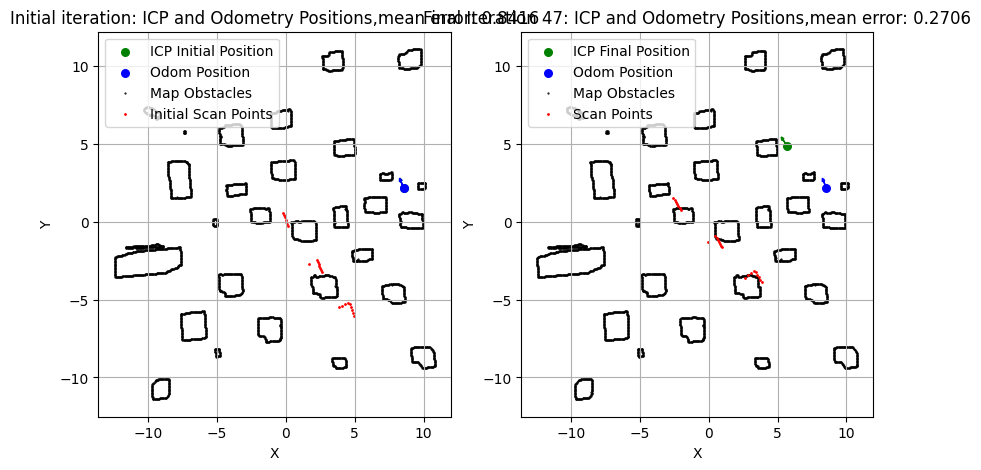

Closest map is map_0012_1771970331425858800.png has a delta of 1.21715768 seconds
Closest scan has a delta of 0.037569313 seconds
mean_error: 0.8085034156755541 after 6 iterations;initial mean error: 0.8395880896800096


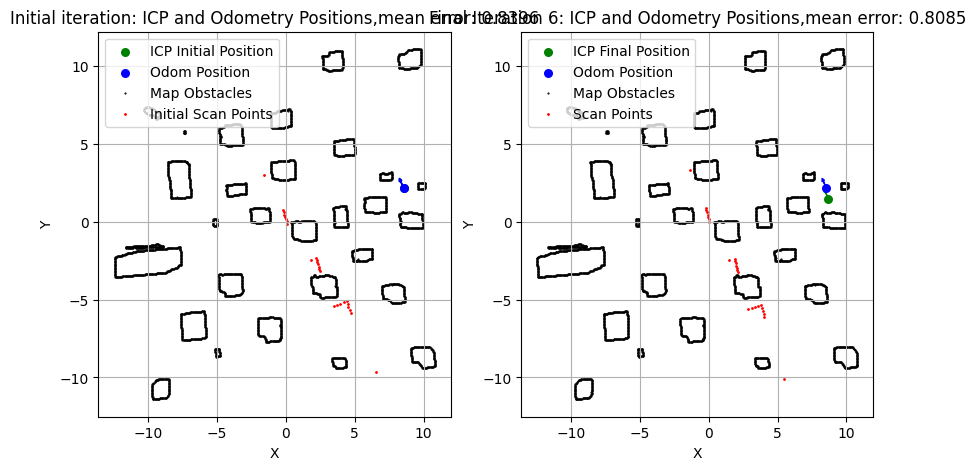

Closest map is map_0012_1771970331425858800.png has a delta of 1.173424374 seconds
Closest scan has a delta of -0.006163993 seconds
mean_error: 0.8085184733365343 after 10 iterations;initial mean error: 0.8565053724910314


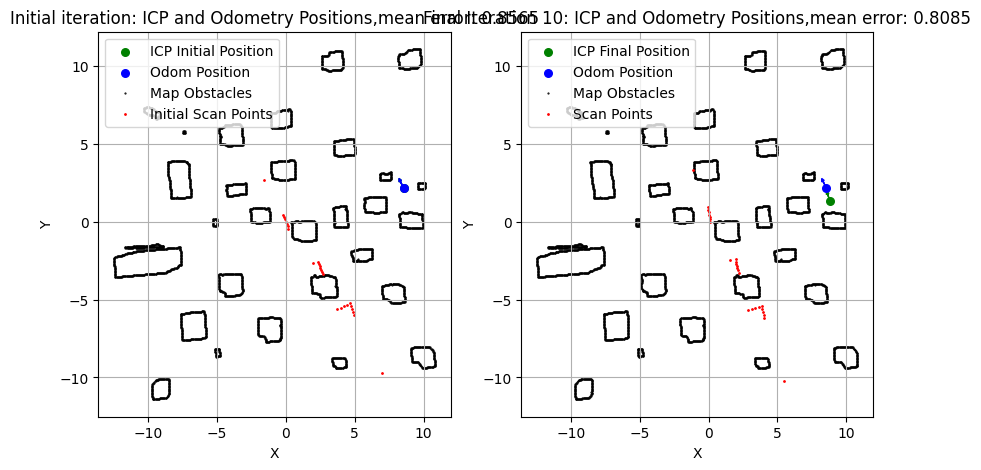

Closest map is map_0012_1771970331425858800.png has a delta of 1.142953078 seconds
Closest scan has a delta of -0.036635289 seconds
mean_error: 0.7883773411407504 after 2 iterations;initial mean error: 0.8787460488765462


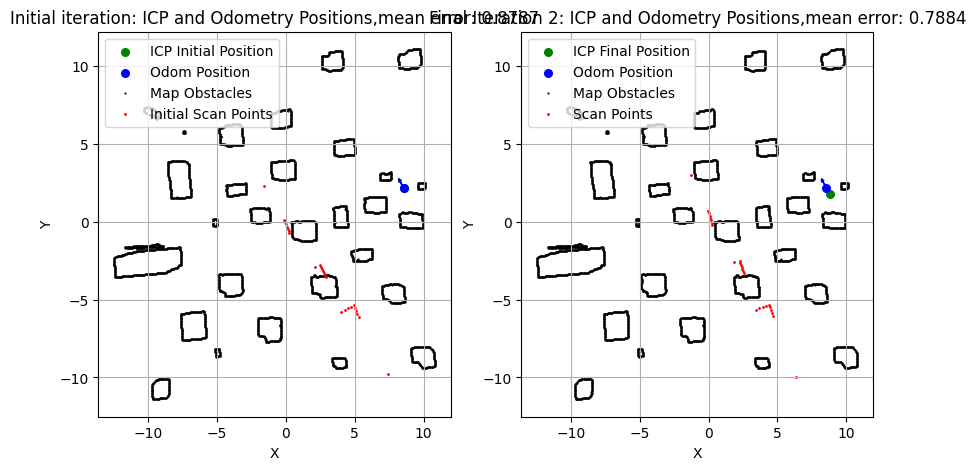

Closest map is map_0012_1771970331425858800.png has a delta of 1.07759435 seconds
Closest scan has a delta of 0.022356063 seconds
mean_error: 0.7665133046414571 after 8 iterations;initial mean error: 0.7716615755948099


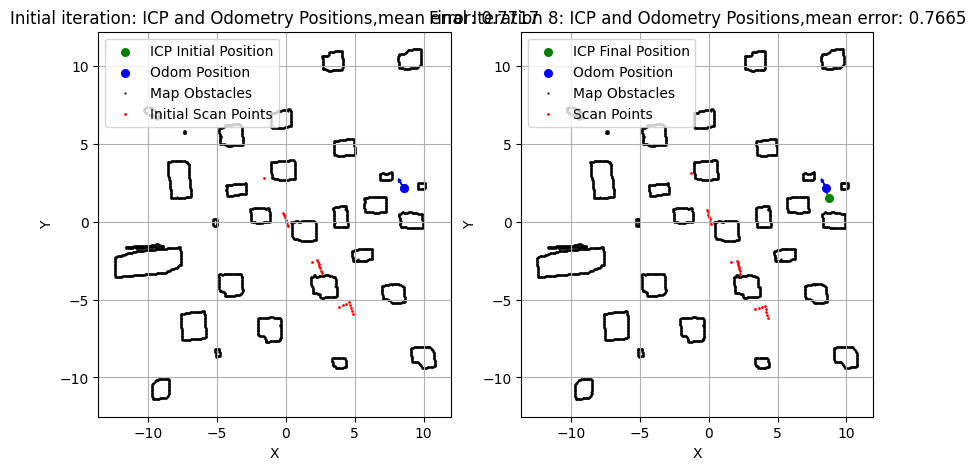

Closest map is map_0012_1771970331425858800.png has a delta of 0.982385375 seconds
Closest scan has a delta of -0.072852912 seconds
mean_error: 0.7665133046414568 after 12 iterations;initial mean error: 0.9392424742013895


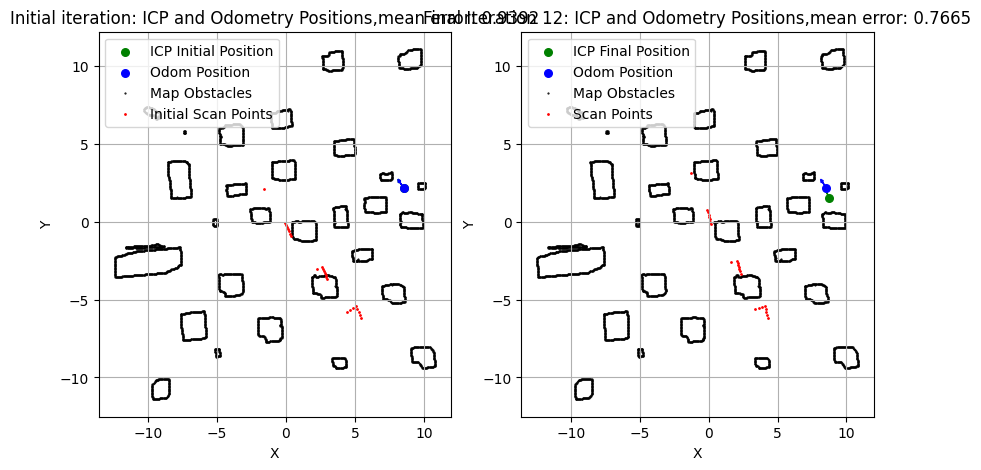

Closest map is map_0012_1771970331425858800.png has a delta of 0.920428966 seconds
Closest scan has a delta of 0.014397016 seconds
mean_error: 0.7865731174081475 after 22 iterations;initial mean error: 0.7955861223425772


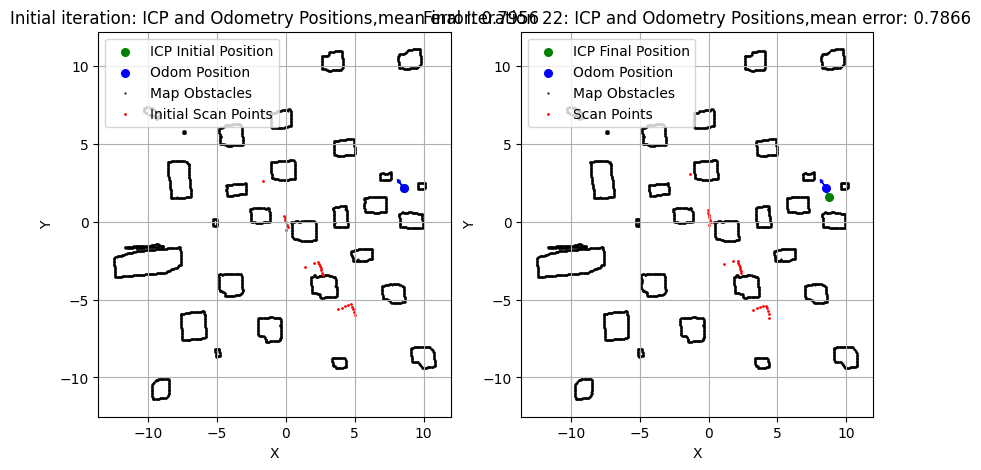

Closest map is map_0012_1771970331425858800.png has a delta of 0.820195804 seconds
Closest scan has a delta of -0.085836146 seconds
mean_error: 0.7865731174081532 after 8 iterations;initial mean error: 0.8246107151722621


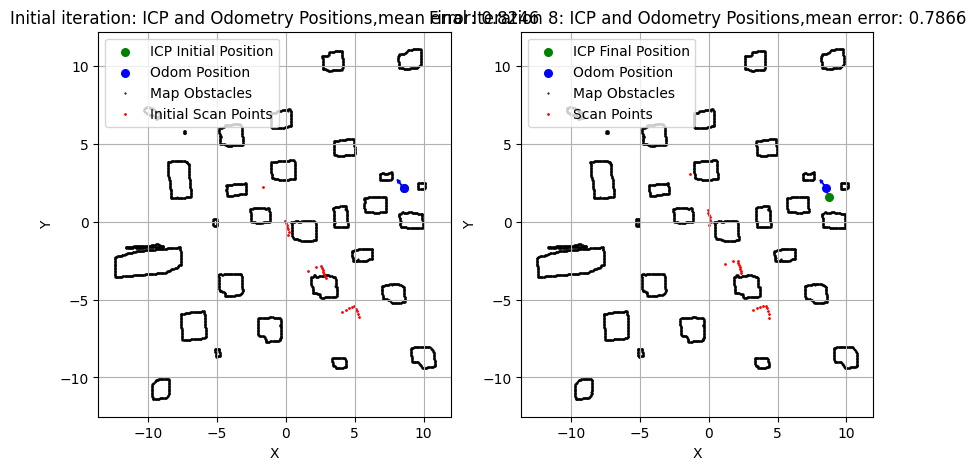

Closest map is map_0012_1771970331425858800.png has a delta of 0.770145617 seconds
Closest scan has a delta of 0.056616447 seconds
mean_error: 0.8049751990249275 after 5 iterations;initial mean error: 0.8082037828027936


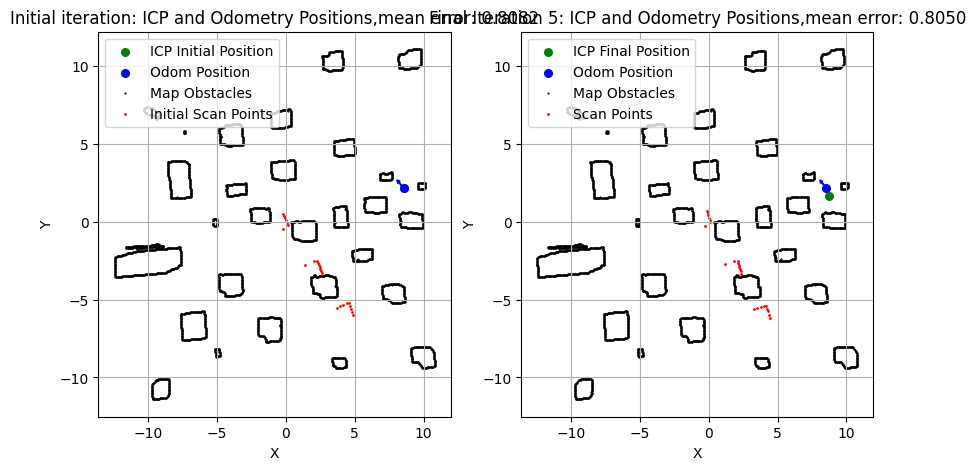

Closest map is map_0012_1771970331425858800.png has a delta of 0.710788196 seconds
Closest scan has a delta of -0.002740974 seconds
mean_error: 0.8049751990249276 after 5 iterations;initial mean error: 0.8224498370846643


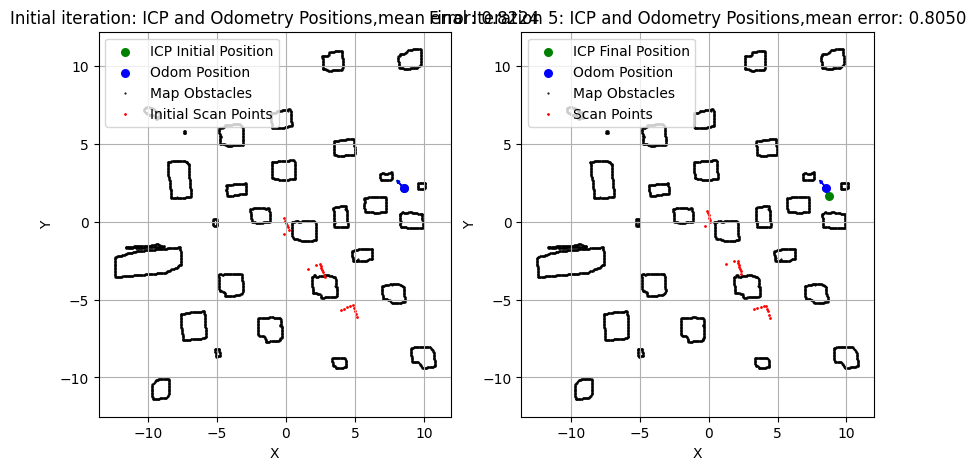

In [58]:
i =0
for t_ns in odom["t_ns"].values:
    # limit to ten values of t_ns for which yaw is greater than 2 radians to save time
    if odom[odom["t_ns"]==t_ns]["yaw"].values[0] > 2:
        i += 1
        if i > 10:
            break
        target = get_map_obstacles_for_odom(t_ns)
        source = get_point_from_scan(t_ns)
        x_od,y_od,theta_od = get_odom(t_ns)
        R_od, t_od = get_odom_transform(x_od, y_od, theta_od)
        icp = icp_pose_pairwise_rms(source, target,R_od,t_od, plot=True)



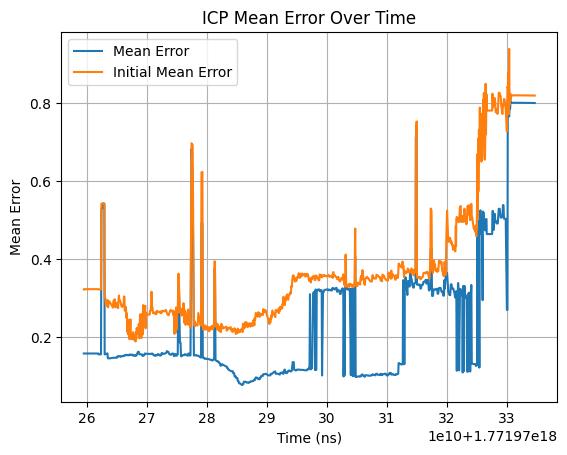

In [59]:
icp_result_df = pd.read_csv("icp_results_points_to_points_pairwise_rms.csv")
# plot mean error and initial mean error over time
plt.plot(odom["t_ns"].values, icp_result_df["mean_error"].values, label="Mean Error")
plt.plot(odom["t_ns"].values, icp_result_df["mean_error_initial"].values, label="Initial Mean Error")
plt.xlabel("Time (ns)")
plt.ylabel("Mean Error")
plt.title("ICP Mean Error Over Time")
plt.legend()
plt.grid()

/tmp/ipykernel_520519/3298684538.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])


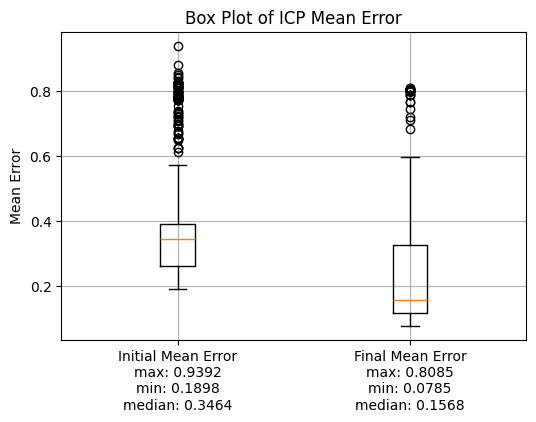

In [60]:
# box plot of mean error and initial mean error with values max min median 
plt.figure(figsize=(6,4))
## add values of max min and median to the box plot labels
initial_mean_error_max = np.max(icp_result_df["mean_error_initial"].values)
initial_mean_error_min = np.min(icp_result_df["mean_error_initial"].values)
initial_mean_error_median = np.median(icp_result_df["mean_error_initial"].values)
final_mean_error_max = np.max(icp_result_df["mean_error"].values)
final_mean_error_min = np.min(icp_result_df["mean_error"].values)
final_mean_error_median = np.median(icp_result_df["mean_error"].values)
plt.boxplot([icp_result_df["mean_error_initial"].values, icp_result_df["mean_error"].values], labels=[f"Initial Mean Error\nmax: {initial_mean_error_max:.4f}\nmin: {initial_mean_error_min:.4f}\nmedian: {initial_mean_error_median:.4f}", f"Final Mean Error\nmax: {final_mean_error_max:.4f}\nmin: {final_mean_error_min:.4f}\nmedian: {final_mean_error_median:.4f}"])
plt.ylabel("Mean Error")
plt.title("Box Plot of ICP Mean Error")
plt.grid()
plt.show()